In [76]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import os
import ast
from matplotlib.ticker import MaxNLocator


This is a notebook to compare the running stats of various different models as they trained, to try to compare model performance

In [77]:
def read_stats(stat_path): 
    """
    Helper function to process a single model's results so we can visualise
    """
    # train stats
    train_stat_df = pd.read_csv(os.path.join(stat_path, "train_epoch_stats.csv"), index_col=0)
    # drop mean true prob per label 
    train_stat_df = train_stat_df.drop(columns=["mean_true_prob_per_label", "calibration_gap", "mean_pred_prob_per_label", "mean_cardinality", "mean_prob_mass"])
    # expand out per label columns 
    train_stat_df["mean_pred_when_positive"] = train_stat_df["mean_pred_when_positive"].apply(ast.literal_eval)
    train_stat_df = train_stat_df.join(
        pd.DataFrame(train_stat_df["mean_pred_when_positive"].tolist(), 
                    columns=["STTC_Pred_When_Pos", 
                            "HYP_Pred_When_Pos", 
                            "MI_Pred_When_Pos", 
                            "CD_Pred_When_Pos", 
                            "AF_Pred_When_Pos"],
                    index=train_stat_df.index)).drop(columns=["mean_pred_when_positive"])
    
    train_stat_df["mean_pred_when_negative"] = train_stat_df["mean_pred_when_negative"].apply(ast.literal_eval)
    train_stat_df = train_stat_df.join(
        pd.DataFrame(train_stat_df["mean_pred_when_negative"].tolist(), 
                    columns=["STTC_Pred_When_Neg", 
                            "HYP_Pred_When_Neg", 
                            "MI_Pred_When_Neg", 
                            "CD_Pred_When_Neg", 
                            "AF_Pred_When_Neg"],
                    index=train_stat_df.index)).drop(columns=["mean_pred_when_negative"])
    
    train_stat_df["STTC_Calib_Gap"] = train_stat_df["STTC_Pred_When_Pos"] - train_stat_df["STTC_Pred_When_Neg"]
    train_stat_df["HYP_Calib_Gap"] = train_stat_df["HYP_Pred_When_Pos"] - train_stat_df["HYP_Pred_When_Neg"]
    train_stat_df["MI_Calib_Gap"] = train_stat_df["MI_Pred_When_Pos"] - train_stat_df["MI_Pred_When_Neg"]
    train_stat_df["CD_Calib_Gap"] = train_stat_df["CD_Pred_When_Pos"] - train_stat_df["CD_Pred_When_Neg"]
    train_stat_df["AF_Calib_Gap"] = train_stat_df["AF_Pred_When_Pos"] - train_stat_df["AF_Pred_When_Neg"]

    val_stat_df = pd.read_csv(os.path.join(stat_path, "val_ranking_stats.csv"), index_col=0)
    val_stat_df["per_label_ap"] = val_stat_df["per_label_ap"].apply(ast.literal_eval)
    val_stat_df = val_stat_df.join(
        pd.DataFrame(val_stat_df["per_label_ap"].tolist(), 
                    columns=["STTC_AP", 
                            "HYP_AP", 
                            "MI_AP", 
                            "CD_AP", 
                            "AF_AP"], 
                    index=val_stat_df.index)).drop(columns=["per_label_ap"])
    val_stat_df["per_label_auroc"] = val_stat_df["per_label_auroc"].apply(ast.literal_eval)
    val_stat_df = val_stat_df.join(
        pd.DataFrame(val_stat_df["per_label_auroc"].tolist(), 
                    columns=["STTC_AUROC", 
                            "HYP_AUROC", 
                            "MI_AUROC", 
                            "CD_AUROC", 
                            "AF_AUROC"], 
                    index=val_stat_df.index)).drop(columns=["per_label_auroc"])
    
    train_losses = pd.read_csv(os.path.join(stat_path, "train_losses.csv"), index_col=0)
    val_losses = pd.read_csv(os.path.join(stat_path, "val_losses.csv"), index_col=0)
    
    return train_stat_df, val_stat_df, train_losses, val_losses

In [78]:
def process_multiple_models_and_collect(model_dict):
    """
    Given a dict of format {model_name: path_to_stats}, unpacks multiple models and saves them as a dictionary
    """
    output_results = {}
    
    for modelname, modelpath in model_dict.items(): 
        output_results[modelname] = read_stats(modelpath)
        
    return output_results

In [79]:
def print_train_val_losses(results_dict, plot=True, figsize = (6, 4)):
    """
    Expects dictionary that is {str: tuple of pd.DataFrame} = {modelname: (train_stats, val_stats, train_losses, val_losses)}
    Optionally plots those training losses as well!
    """
    collected_train_losses = {}
    collected_val_losses = {}
    for modelname, resultstuple in results_dict.items():
        _, _, train_losses, val_losses = resultstuple
        collected_train_losses[modelname] = train_losses
        collected_val_losses[modelname] = val_losses
    
    if plot:
        fig, (ax0, ax1) = plt.subplots(2, 1, sharex=True, figsize=figsize)
        for modelname in results_dict.keys():
            ax0.plot(collected_train_losses[modelname], '-x', label=f"{modelname}")
            ax1.plot(collected_val_losses[modelname], '-x', label=f"{modelname}")
            ax0.set_ylabel("Train Loss")
            ax1.set_ylabel("Val Loss")
            ax1.set_xlabel("Epoch")
            # set to integer ticks
            ax0.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax0.legend()
            ax1.legend()
            fig.tight_layout()

    return collected_train_losses, collected_val_losses

In [80]:
def collect_specified_metric(results_dict, metric_name, metric_in_val=True, plot=True, figsize=(6, 4), yrange=None):
    """
    Expects dictionary that is {str: tuple of pd.DataFrame} = {modelname: (train_stats, val_stats, train_losses, val_losses)}
    Collects the data for that metric across models and returns 
    Optionally plots if you want
    """
    collected_metric = {}
    for modelname, resultstuple in results_dict.items():
        train_stats, val_stats, _, _ = resultstuple
        if metric_in_val: 
            collected_metric[modelname] = val_stats[metric_name].values
        else: 
            collected_metric[modelname] = train_stats[metric_name].values
            
    if plot: 
        fig, ax = plt.subplots(figsize=figsize)
        for modelname in results_dict.keys():
            ax.plot(collected_metric[modelname], '-x', label=f"{modelname}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(f"{metric_name}")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        if yrange is not None: 
            ax.set_ylim(yrange[0], yrange[1])
        ax.legend()
        fig.tight_layout()
            
    return collected_metric

In [81]:
model_dict = {
    "Asymm": os.path.join(os.path.expanduser("~"), "Downloads", "Model_Asymm_Loss"), 
    "Focal": os.path.join(os.path.expanduser("~"), "Downloads", "Model_Focal_Loss"),
    "BCE_Weighted": os.path.join(os.path.expanduser("~"), "Downloads", "Model_BCE_Weighted"),
    "BCE_Unweighted": os.path.join(os.path.expanduser("~"), "Downloads", "Model_BCE_Unweighted")}
output = process_multiple_models_and_collect(model_dict)

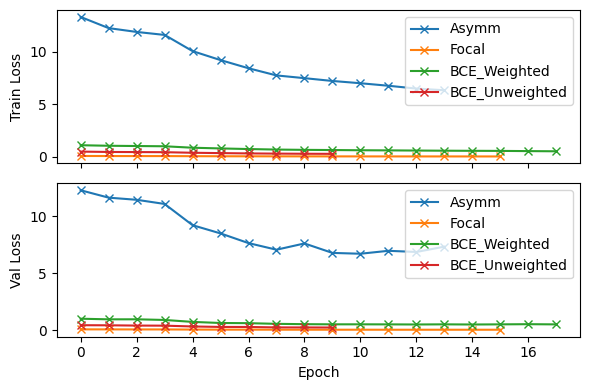

In [82]:
train_losses, val_losses = print_train_val_losses(output)

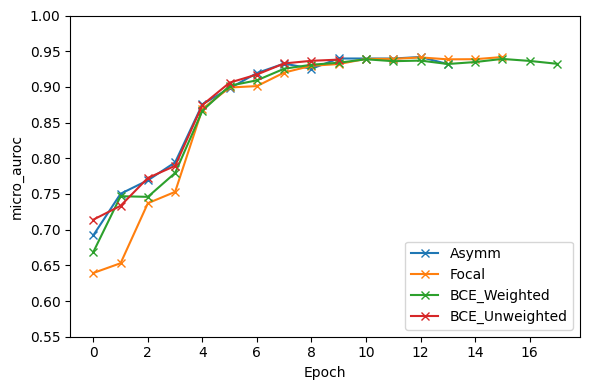

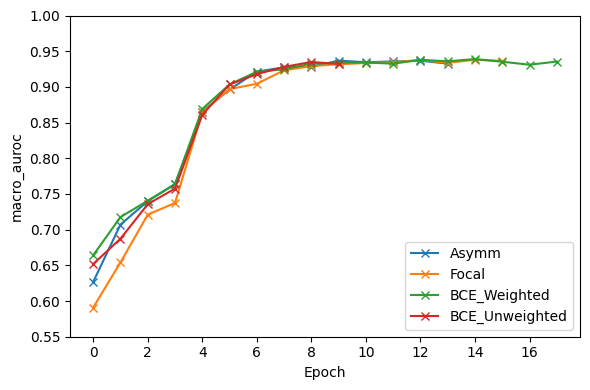

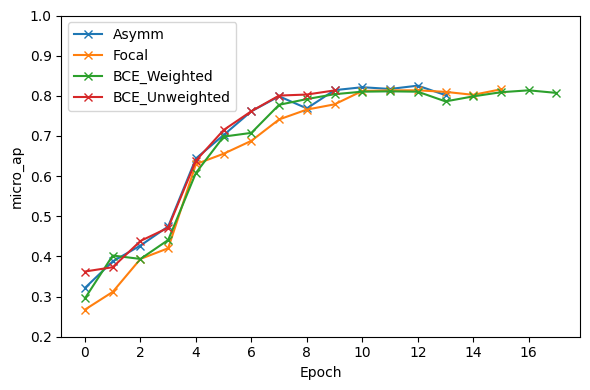

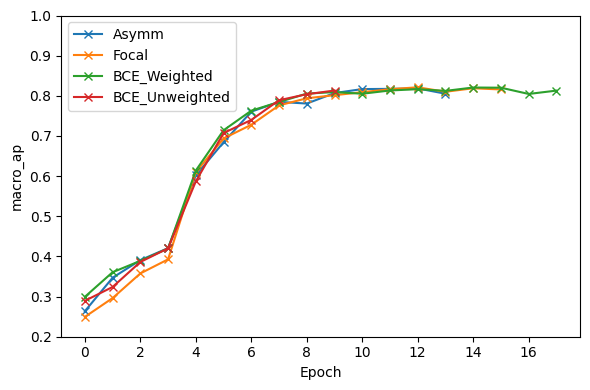

In [83]:
micro_auroc = collect_specified_metric(output, metric_name="micro_auroc", yrange=[0.55, 1.0])
macro_auroc = collect_specified_metric(output, metric_name="macro_auroc", yrange=[0.55, 1.0])

micro_ap = collect_specified_metric(output, metric_name="micro_ap", yrange=[0.2, 1.0])
macro_ap = collect_specified_metric(output, metric_name="macro_ap", yrange=[0.2, 1.0])

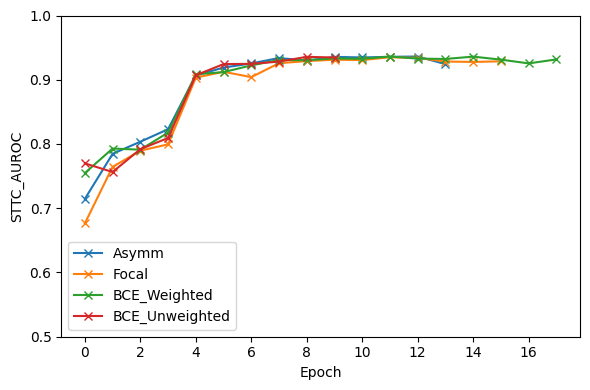

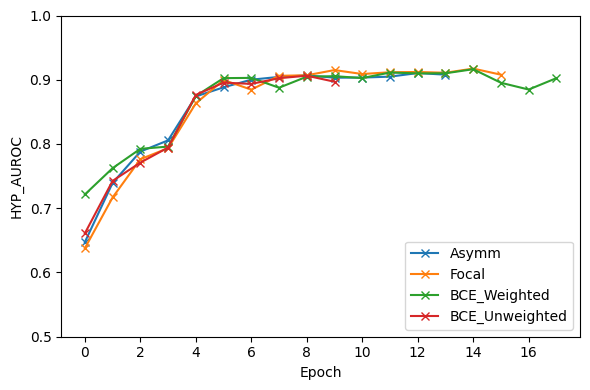

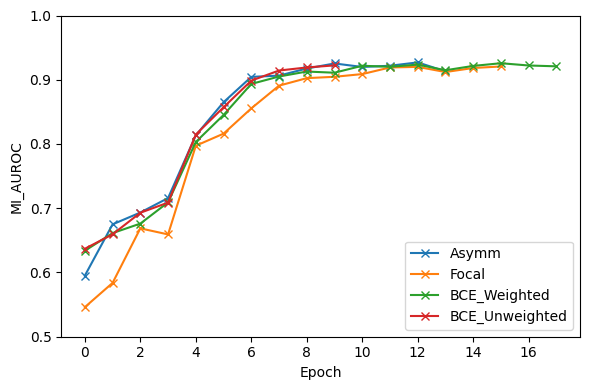

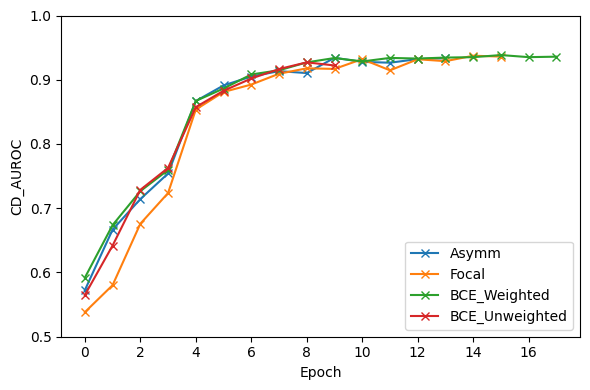

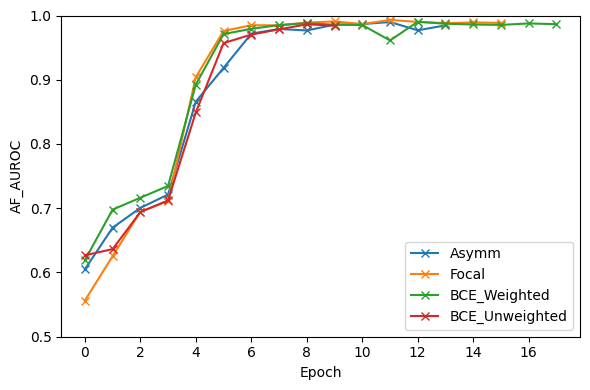

In [84]:
sttc_auroc = collect_specified_metric(output, metric_name="STTC_AUROC", yrange=[0.5, 1.0])
hyp_auroc = collect_specified_metric(output, metric_name="HYP_AUROC", yrange=[0.5, 1.0])
mi_auroc = collect_specified_metric(output, metric_name="MI_AUROC", yrange=[0.5, 1.0])
cd_auroc = collect_specified_metric(output, metric_name="CD_AUROC", yrange=[0.5, 1.0])
af_auroc = collect_specified_metric(output, metric_name="AF_AUROC", yrange=[0.5, 1.0])

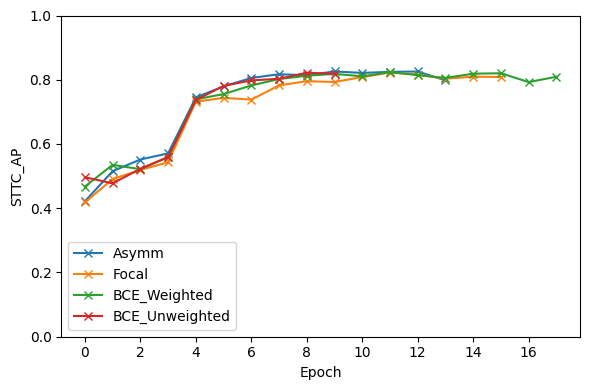

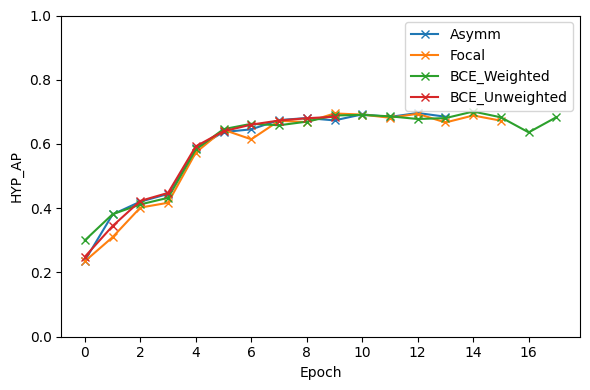

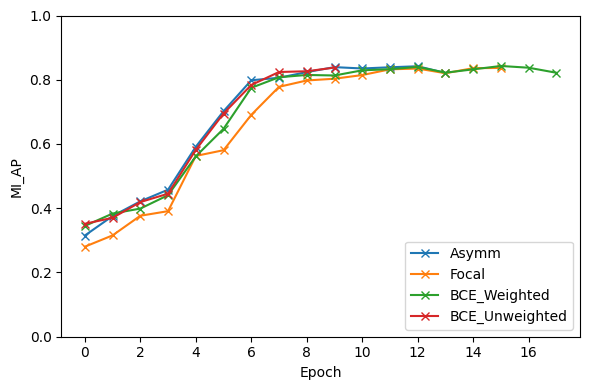

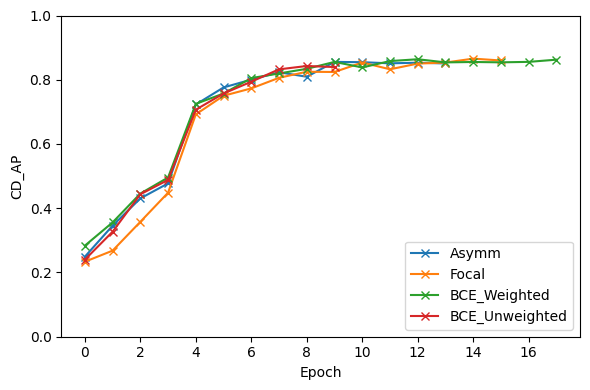

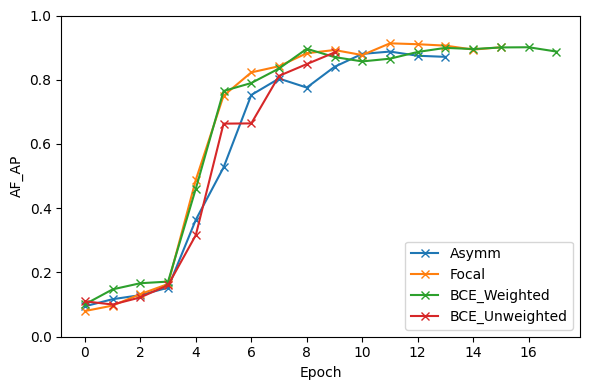

In [85]:
sttc_ap = collect_specified_metric(output, metric_name="STTC_AP", yrange=[0.0, 1.0])
hyp_ap = collect_specified_metric(output, metric_name="HYP_AP", yrange=[0.0, 1.0])
mi_ap = collect_specified_metric(output, metric_name="MI_AP", yrange=[0.0, 1.0])
cd_ap = collect_specified_metric(output, metric_name="CD_AP", yrange=[0.0, 1.0])
af_ap = collect_specified_metric(output, metric_name="AF_AP", yrange=[0.0, 1.0])